In [5]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
import os
import numpy as np
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import typing
from mpl_toolkits.mplot3d import Axes3D

import glob

In [6]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

# Klasa, która ułatwia wczytywanie obrazków z danego folderu
class ImageDataset:
    def __init__(self, image_dir: str):
        self.filelist = glob.glob(image_dir + "/*.jpg")
        self.IMAGE_DIMS = (512, 512)

    def __len__(self):
        return len(self.filelist)

    def __getitem__(self, idx) -> np.ndarray:
        with Image.open(self.filelist[idx]) as image:
            image = image.convert('RGB')
            image = image.resize(self.IMAGE_DIMS)
            return np.array(image)

    def __iter__(self) -> typing.Iterator[np.ndarray]:
        return (self[i] for i in range(len(self.filelist)))

# Poniżej znajdziesz definicje MSE oraz kosztu użycia kolorów
# Pamiętaj, żeby przy ewaluacji liczyć je w przestrzeni RGB, tzn. na wartościach całkowitych z przdziału [0, 255]
# Skalowanie jest dopuszczalne tylko podczas treningu!

# Zdefiniujmy kryterium oceny jakości kwantyzacji
# Użyjemy do tego błędu średniokwadratowego (mean square error - MSE)
def mse(img, img_quant):
  return ((img_quant.astype(np.float32) - img.astype(np.float32))**2).mean()

def err_array(img,img_quant):
    return (img_quant.astype(np.int8) - img.astype(np.int8)).reshape(-1,3)

def color_err_array(color_pack):
    vertices = np.array([
        [0, 0, 0], [0, 0, 255], [0, 255, 0], [0, 255, 255],
        [255, 0, 0], [255, 0, 255], [255, 255, 0], [255, 255, 255]
    ])
    return color_pack - vertices[np.argmin(
    np.sum(
        (color_pack[:,None,:] - vertices[None,:,:])**2
        ,axis=2)
    ,axis=1)]

# Następnie zdefinujmy koszt użycia kolorów
# Im bliżej danemu kolorowi do "prostych" kolorów, tym mniejszy koszt jego użycia
def color_cost(img_quant):
    vertices = np.array([
        [0, 0, 0], [0, 0, 255], [0, 255, 0], [0, 255, 255],
        [255, 0, 0], [255, 0, 255], [255, 255, 0], [255, 255, 255]
    ])
    
    pixels = img_quant.reshape(-1,3)
    
    differences = pixels[:, np.newaxis, :] - vertices[np.newaxis, :, :]
    squared_distances = np.sum(differences**2, axis=2)
    costs = np.sqrt(np.min(squared_distances, axis=1))

    return np.mean(costs), np.max(costs)


# Całkowite kryterium zdefiniowane w treści zadania
def quantization_score(img, img_quant):
    assert img.dtype == np.uint8
    assert img_quant.dtype == np.uint8
    assert len(np.unique(img_quant.reshape(-1,3), axis=0)) == 37
       
    mse_cost = mse(img, img_quant)
    mean_color_cost, max_color_cost = color_cost(img_quant)
    score = mse_cost * 2 + max_color_cost * 21 + mean_color_cost * 42
    print(f'MSE: {mse_cost:.4f}, max_color_cost: {max_color_cost:.4f}, mean_color_cost: {mean_color_cost:.4f}')
    print(f'Score: {score:.4f}')
    return score

# Wyświetl zestawienie oryginału i zkwantyzowanego obrazka
def show_quantization_results(original, quantized):
        _, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(original)
        ax[0].set_title("Oryginał")
        ax[0].axis("off")

        ax[1].imshow(quantized)
        ax[1].set_title("Wynik kwantyzacji")
        ax[1].axis("off")
        plt.show()

def evaluate_algorithm(quantization_algorithm, data_dir):
    dataset = ImageDataset(data_dir)
    scores = []
    for image in dataset:
        quantized_image = quantization_algorithm(image)
        show_quantization_results(image, quantized_image)
        score = quantization_score(image, quantized_image)
        scores.append(score)
    return np.mean(scores)


def innit_cube(x):
    corners = np.array([
    [0, 0, 0],
    [0, 0, 255],
    [0, 255, 0],
    [0, 255, 255],
    [255, 0, 0],
    [255, 0, 255],
    [255, 255, 0],
    [255, 255, 255]])

    all_points = np.concatenate([corners,x])
    xs = all_points[:,0]
    ys = all_points[:,1]
    zs = all_points[:,2]

    rgba = np.hstack([
    all_points/255,
    np.ones((all_points.shape[0], 1))
    ])

    #rgba[8+min(x.shape[0],37):,:3] = 0.5
    #rgba[8+min(x.shape[0],37):,3] = 0.4

    rgba[8:,:3] = 0.5 #szary kolor
    rgba[8:,3] = 0.4
    
    # Tworzenie wykresu
    fig = plt.figure(figsize=(10,5))
    ax = fig.add_subplot(111, projection='3d',)
    
    # Rysowanie punktów
    ax.scatter(xs, ys, zs, c=rgba, s=2)

    ax.set_xlabel('R')
    ax.set_ylabel('G')
    ax.set_zlabel('B')
    ax.set_xlim([0, 255])
    ax.set_ylim([0, 255])
    ax.set_zlim([0, 255])
    ax.grid(True)
    plt.show()
    #return fig

def _cube(all_points):
    corners = np.array([
    [0, 0, 0],
    [0, 0, 255],
    [0, 255, 0],
    [0, 255, 255],
    [255, 0, 0],
    [255, 0, 255],
    [255, 255, 0],
    [255, 255, 255]])

    xs = all_points[:,0]
    ys = all_points[:,1]
    zs = all_points[:,2]

    rgba = np.hstack([
    all_points/255,
    np.ones((all_points.shape[0], 1))
    ])
    
    # Tworzenie wykresu
    fig = plt.figure(figsize=(10,5))
    ax = fig.add_subplot(111, projection='3d',)
    
    # Rysowanie punktów
    ax.scatter(xs, ys, zs, c=rgba, s=50)

    ax.set_xlabel('R')
    ax.set_ylabel('G')
    ax.set_zlabel('B')
    ax.set_xlim([0, 255])
    ax.set_ylim([0, 255])
    ax.set_zlim([0, 255])
    ax.grid(True)
    plt.show()

def cube(fig,x):
    ax = fig.axes[0]
    xs = x[:,0]
    ys = x[:,1]
    zs = x[:,2]

    rgba = np.hstack([
    x/255,
    np.ones((x.shape[0], 1))
    ])

    rgba[:,3] = 0.9
    # Rysowanie punktów
    ax.scatter(xs, ys, zs, c=rgba, s=80,zorder=0)
    return fig
    #plt.show()

In [7]:
def quant(color_pack):
    labels = np.argmin(((pixel_matrix[:, None, :] - color_pack[None, :, :])**2).sum(axis=2),axis=1)
    quantized_image = color_pack[labels].reshape(512,512,3).astype(np.uint8)
    return quantized_image,labels.reshape(512,512)

def starter_pack(img):
    from sklearn.cluster import KMeans
    pixels = img.reshape(-1,3)
    kmeans = KMeans(n_clusters=37).fit(pixels)
    colors = kmeans.cluster_centers_
    #labels = kmeans.predict(pixels)
    #quantized_image = colors[labels].reshape(img.shape).astype(np.uint8)
    return colors.astype(int),pixels

MSE: 111.1261, max_color_cost: 205.2438, mean_color_cost: 129.1574
Score: 9956.9837


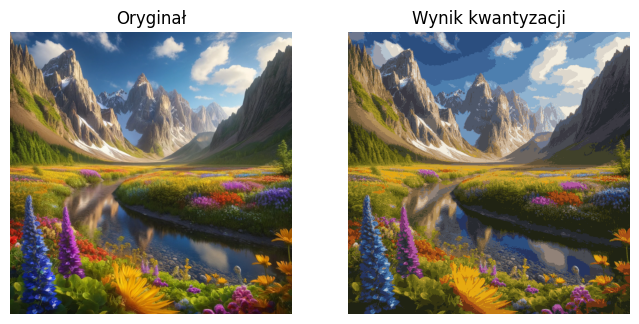

MSE: 239.1101, max_color_cost: 165.3904, mean_color_cost: 115.9405
Score: 8820.9213
MSE: 290.4948, max_color_cost: 153.1470, mean_color_cost: 112.9515
Score: 8541.0414
MSE: 321.7786, max_color_cost: 147.4110, mean_color_cost: 111.5186
Score: 8422.9672
MSE: 341.9923, max_color_cost: 147.4788, mean_color_cost: 110.9443
Score: 8440.6992
MSE: 362.8526, max_color_cost: 149.9266, mean_color_cost: 110.4666
Score: 8513.7607
MSE: 381.6339, max_color_cost: 151.0430, mean_color_cost: 110.0894
Score: 8558.9283
MSE: 392.0226, max_color_cost: 152.1644, mean_color_cost: 110.1292
Score: 8604.9248
MSE: 211.9786, max_color_cost: 186.7217, mean_color_cost: 128.8512
Score: 9756.8628
MSE: 275.3335, max_color_cost: 155.5924, mean_color_cost: 117.2531
Score: 8742.7388
MSE: 322.0165, max_color_cost: 143.3946, mean_color_cost: 114.2793
Score: 8455.0504
MSE: 363.2019, max_color_cost: 143.8263, mean_color_cost: 112.4234
Score: 8468.5403
MSE: 392.2440, max_color_cost: 147.2583, mean_color_cost: 111.3657
Score: 85

KeyboardInterrupt: 

In [125]:
#test = ImageDataset("valid_data")
test = ImageDataset("train_data")
for _ in range(len(test)):
    solve(test[_])

In [ ]:
#KAZDORAZOWO

In [124]:
def solve(img):
    #CASE BASE
    global pixel_matrix
    color_pack, pixel_matrix = starter_pack(img)
    
    img_quant, clabels = quant(color_pack)
    sc = quantization_score(img, img_quant)
    show_quantization_results(img,img_quant)
    
    for _ in range(101):
        unique, counts = np.unique(clabels, return_counts=True)
        impact_dict = dict(set(zip(unique,counts)))
        
        em = err_array(img,img_quant)
        for i in range(37):
            #v1 = -10*(impact_dict[i]/(512**2)) *color_err_array(color_pack)[i] 
            v1 = -0.2*(color_err_array(color_pack)[i])
            v2 = -1*em[clabels.reshape(-1)==i].mean(axis=0)
            #print(f":{i}-{color_pack[i]}",v1,v2,impact_dict[i],impact_dict[i]/(512**2))
            color_pack[i] += (v1+v2
            #technicznie color moze wypasc poza 0,255
                               ).astype(int)# %jego wyplywu na blad liczby wystapien
            color_pack[i] = np.abs(color_pack[i])
            color_pack[i] = np.where(color_pack[i]<=255,color_pack[i],np.random.randint(150,255))
        
        if np.unique(color_pack,axis=0).shape[0] != 37:
            pass
            print("!!")
            #_c_, dup = np.unique(color_pack,axis=0,return_index=True)
            #color_pack, pixel_matrix = starter_pack(img)
            #print("!!",dup)
        elif color_pack.shape[0] != 37:
            np.concatenate([color_pack,np.random.randint(0,255,(37-color_pack.shape[0],3))])
        
        #print(color_pack)
        img_quant, clabels = quant(color_pack)
        if np.unique(clabels).shape[0] != 37:
            blank = [x for x in range(37) if x not in [set(np.unique(clabels))]]
            for el in blank:
                pixels = pixel_matrix.reshape(-1, 3)
                color_pack[el] = pixels[np.random.randint(len(pixels))]
            img_quant, clabels = quant(color_pack)
            
        sc = quantization_score(img, img_quant)
        
        #_cube(color_pack)
        #if sc<8900:
         #   show_quantization_results(img,img_quant)
        if sc<8000:
            #print("!",color_pack)
            show_quantization_results(img,img_quant)
            break

In [116]:
color_err_array(color_pack)[i]

array([-17, -49,  28])

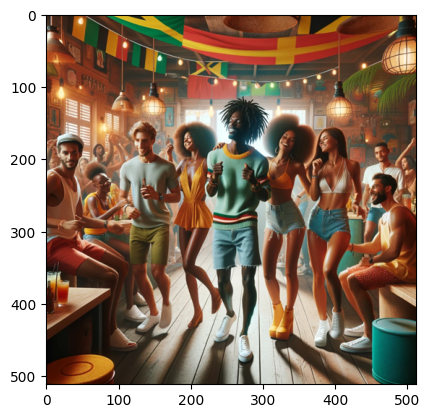

In [73]:
test = ImageDataset("train_data")
img = test[5]
plt.imshow(img)

In [ ]:
cube(np.concatenate([np.random.randint(0,256,(37,3))
                     ,np.unique(img.reshape(-1,3),axis=0)
                    ]))

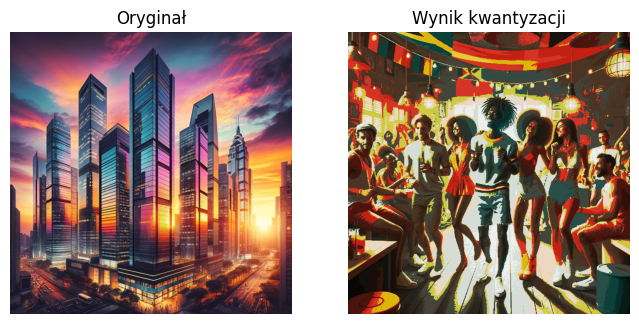

In [95]:
show_quantization_results(img,img_quant)

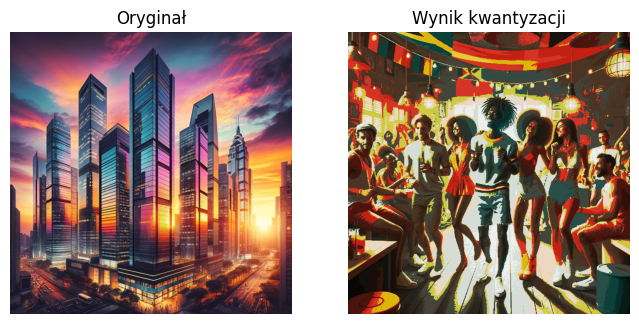

In [113]:
show_quantization_results(img,img_quant)